In [3]:
import cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
from glob import glob
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

In [11]:
glob_path = [i for i in glob('Dataset\*\*\*.mp4')]
output_label = [i for i in glob('Dataset\*\*')]

glob_path,output_label

(['Dataset\\Adjectives\\Blind\\1-1.mp4',
  'Dataset\\Adjectives\\Blind\\1-2.mp4',
  'Dataset\\Adjectives\\Blind\\1-3.mp4',
  'Dataset\\Adjectives\\Blind\\1-4.mp4',
  'Dataset\\Adjectives\\Blind\\1-5.mp4',
  'Dataset\\Adjectives\\Blind\\1-6.mp4',
  'Dataset\\Adjectives\\Blind\\1-7.mp4',
  'Dataset\\Adjectives\\Blind\\1-8.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-1.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-2.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-3.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-4.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-5.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-6.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-7.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-8.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-1.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-2.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-3.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-4.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-5.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-6.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-7.mp4',
  'Dataset\\Adjectives\\Fla

In [3]:
random_video = random.choice(glob_path)
print(random_video.split("\\")[-2:])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

['Deaf', 'Deaf-1.mp4']
Video Resolution: 1280.0 x 720.0
FPS: 30.0


In [4]:
cap = cv2.VideoCapture(random_video)
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (720, 1280, 3)


In [5]:
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

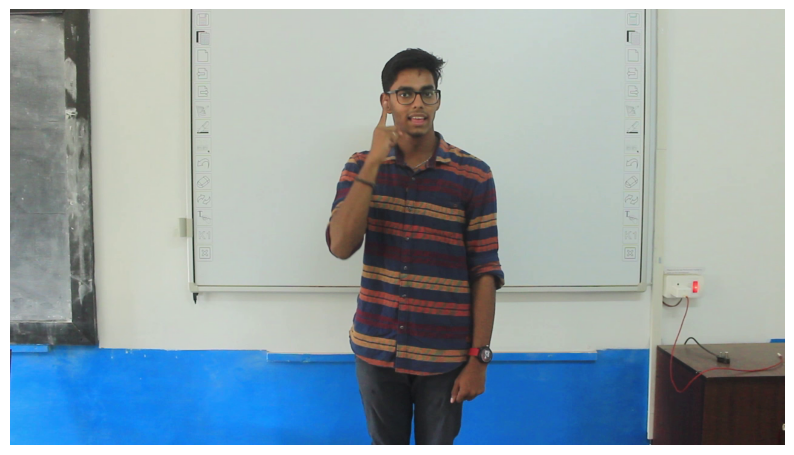

In [6]:
display_cv2_img(img)
cap.release()

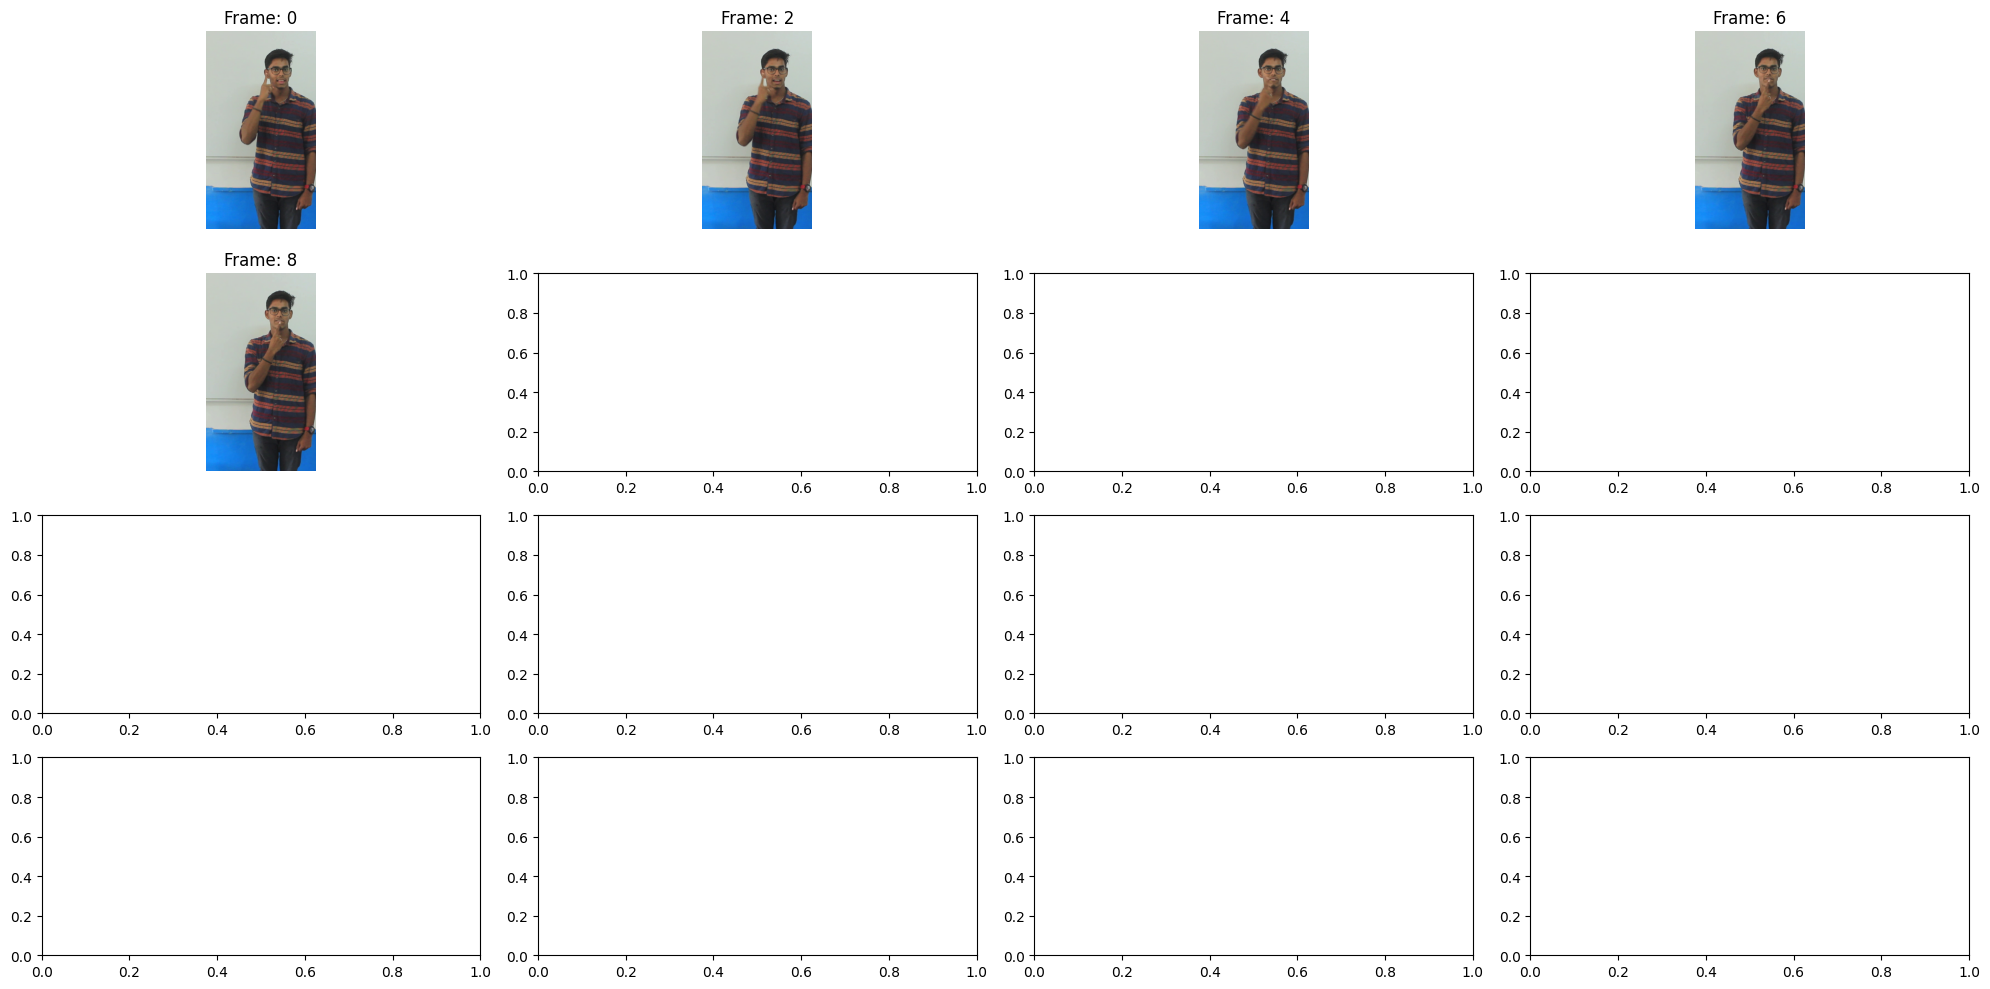

In [7]:
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.flatten()

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    img = img[:,400:800]
    
    if ret == False:
        break
    if frame % 2 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()
cap.release()

## Vedio Augmentaion

1. Org  
2. Centre Crop
3. Flip
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred
8. Frame Skipping

### Centre Crop

In [10]:
def centered_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 30
    width = 400
    height = 720
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,400:800] # Cropping
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Flip


In [8]:
def flip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1280
    height = 720
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,::-1] # Flipping
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Downsampling

In [7]:
def downsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    
    VIDEO_CODEC = "MP4V"
    fps = 30
    width = 640
    height = 360
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrDown(img) # Downsampling
        # print(img.shape)
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Upsampling


In [6]:
def upsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 3840
    height = 2160
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))



    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrUp(img) # Upsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Clipping


In [12]:
def clip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1920
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    counter = 0
    for frame in range(n_frames):
        ret, img = cap.read()
        if ret == False:
            break
        
        if counter >= 10 and counter < n_frames-20:    
            out.write(img)
        
        counter += 1

    out.release()
    cap.release()


### Horizontal Crop

In [13]:
def horizontal_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 30
    height = 590
    width = 1280
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[0:height] 
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Speeding Up

In [2]:
def fast_video(org_video, save_path, cap, n_frames, speed):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 30 * speed
    height = 720
    width = 1280
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read() 
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

In [ ]:
# input_video = "Dataset\Adjectives\Blind\\1-2.mp4"
# cap = cv2.VideoCapture(input_video)
# n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))      

# # save_path = "test.mp4"
# fast_video(input_video, "test.mp4", cap, n_frames,1.1)
# fast_video(input_video, "test1.mp4", cap, n_frames,1.25)
# fast_video(input_video, "test2.mp4", cap, n_frames,1.35)

In [66]:
for label in tqdm(glob('Dataset\*\*')): 
    label_name = " ".join(((label.split("\\")[-1]).split(" "))[1:]) # First seprated the label from dir then sep the label from its number and then join the label
    
    folder = "Cropped"

    os.makedirs(os.path.join(label,folder), exist_ok=True)
    videos = os.listdir(label)
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):
        if "Cro" in video:
            continue
        input_video = os.path.join(label, video)
        cap = cv2.VideoCapture(input_video)
        n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,folder,f"{video[:-4]}.mp4")
        horizontal_video(input_video, save_path, cap, n_frames)

  0%|          | 0/10 [00:00<?, ?it/s]

Blind:   0%|          | 0/9 [00:00<?, ?it/s]

Deaf:   0%|          | 0/9 [00:00<?, ?it/s]

Flat:   0%|          | 0/9 [00:00<?, ?it/s]

Happy:   0%|          | 0/16 [00:00<?, ?it/s]

...

Quiet:   0%|          | 0/22 [00:00<?, ?it/s]

Rich:   0%|          | 0/9 [00:00<?, ?it/s]

sad:   0%|          | 0/9 [00:00<?, ?it/s]

Slow:   0%|          | 0/19 [00:00<?, ?it/s]

Thick:   0%|          | 0/9 [00:00<?, ?it/s]

## Genrating all the augmented content


In [13]:
for label in tqdm(glob('Dataset\*\*')): 
    os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
    videos = os.listdir(label)[1:]
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):        
        input_video = os.path.join(label, video)
        n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
        centered_video(input_video, save_path, cap, n_frames)

        # save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
        # flip_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
        downsample_video(input_video, save_path, cap, n_frames)
        
        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_1_1X.mp4")
        fast_video(input_video, save_path, cap, n_frames,1.1)
        
        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_1_25X.mp4")
        fast_video(input_video, save_path, cap, n_frames,1.25)
        
        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_1_35X.mp4")
        fast_video(input_video, save_path, cap, n_frames,1.35)

        # save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
        # upsample_video(input_video, save_path, cap, n_frames)
    

  0%|          | 0/10 [00:00<?, ?it/s]

Blind:   0%|          | 0/8 [00:00<?, ?it/s]

Deaf:   0%|          | 0/8 [00:00<?, ?it/s]

Flat:   0%|          | 0/8 [00:00<?, ?it/s]

Happy:   0%|          | 0/15 [00:00<?, ?it/s]

...

Quiet:   0%|          | 0/21 [00:00<?, ?it/s]

Rich:   0%|          | 0/8 [00:00<?, ?it/s]

sad:   0%|          | 0/8 [00:00<?, ?it/s]

Slow:   0%|          | 0/18 [00:00<?, ?it/s]

Thick:   0%|          | 0/8 [00:00<?, ?it/s]

## Extracting mediapipe points from augmented vedios

In [8]:
# Setting up for mediapipe extraction of augmented videos
import mediapipe as mp
import utils

mp_holistic = mp.solutions.holistic 
mp_drawing = mp.solutions.drawing_utils 

mp_utils = utils.MediapipeUtils(mp_holistic, mp_drawing)

In [10]:
DATA_PATH = "MP_data\\"

mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5)

video = "test.mp4"

cap = cv2.VideoCapture(video)
all_keypoints = []
keypoints = np.array(None)

while cap.isOpened():           
    #Read feed
    ret, frame = cap.read()
    if not ret:
        break
    
    #Make detections
    image, results = mp_utils.mediapipe_detection(frame, holistic)
        
    #Collecting 3D landmarks for a single frame
    keypoints = mp_utils.extract_keypoints(results)
    all_keypoints.append(keypoints)        
    
all_keypoints = np.vstack(all_keypoints)
print(all_keypoints.shape)

#Saving Landmarks
path = video.split("/")

#Getting Current action of the video
action = " ".join((video.split("\\")[-3]).split(" ")[1:]) 

#Get the sequence number
sequence = video.split("\\")[-1][:-4]

npy_path = os.path.join(DATA_PATH, action, sequence)
print(npy_path)

# np.save(npy_path, all_keypoints)

cap.release()

(9, 132)


IndexError: list index out of range

In [ ]:
DATA_PATH = "MP_data\\"
mp_holistic = mp.solutions.holistic
holistic = mp_holistic.Holistic(min_detection_confidence=0.7, min_tracking_confidence=0.7)



for label in tqdm(glob('Dataset\*\*')): 
    
    vedios = os.listdir(os.path.join(label,"Augmentation"))
       
    for video in tqdm(vedios,desc=label.split("\\")[-2]):             
        
        try:
            video = os.path.join(label,"Augmentation",video)
            
            cap = cv2.VideoCapture(video)
            all_keypoints = []
            keypoints = np.array(None)
                
            while cap.isOpened():           
                # Read feed
                ret, frame = cap.read()
                if not ret:
                    break
                
                # Make detections
                image, results = mp_utils.mediapipe_detection(frame, holistic)
                    
                #Collecting 3D landmarks for a single frame
                keypoints = mp_utils.extract_keypoints(results)
                
                all_keypoints.append(keypoints)        
                
                    
            all_keypoints = np.vstack(all_keypoints)
            
            # Saving Landmarks
            path = video.split("/")
            
            # print(video)
            # Getting Current action of the video
            action = video.split("\\")[-3] 
            
            #Get the sequence number
            sequence = video.split("\\")[-1][:-4]
            
            npy_path = os.path.join(DATA_PATH, action, sequence)
            
            # print(npy_path)
            
            np.save(npy_path, all_keypoints)
            
            cap.release()
        except:
            pass
    
    # print(all_keypoints.shape)

  0%|          | 0/10 [00:00<?, ?it/s]

Adjectives:   0%|          | 0/16 [00:00<?, ?it/s]

MP_data\Blind\1-2_centered
MP_data\Blind\1-2_downsampled
MP_data\Blind\1-3_centered
MP_data\Blind\1-3_downsampled
MP_data\Blind\1-4_centered
MP_data\Blind\1-4_downsampled
MP_data\Blind\1-5_centered
MP_data\Blind\1-5_downsampled
MP_data\Blind\1-6_centered
MP_data\Blind\1-6_downsampled
MP_data\Blind\1-7_centered
MP_data\Blind\1-7_downsampled
MP_data\Blind\1-8_centered
MP_data\Blind\1-8_downsampled


Adjectives:   0%|          | 0/16 [00:00<?, ?it/s]

MP_data\Deaf\Deaf-1_centered
MP_data\Deaf\Deaf-1_downsampled
MP_data\Deaf\Deaf-2_centered
MP_data\Deaf\Deaf-2_downsampled
MP_data\Deaf\Deaf-3_centered
MP_data\Deaf\Deaf-3_downsampled
MP_data\Deaf\Deaf-4_centered
MP_data\Deaf\Deaf-4_downsampled
MP_data\Deaf\Deaf-5_centered
MP_data\Deaf\Deaf-5_downsampled
MP_data\Deaf\Deaf-6_centered
MP_data\Deaf\Deaf-6_downsampled
MP_data\Deaf\Deaf-7_centered
MP_data\Deaf\Deaf-7_downsampled
MP_data\Deaf\Deaf-8_centered
MP_data\Deaf\Deaf-8_downsampled


...

Adjectives:   0%|          | 0/36 [00:00<?, ?it/s]

MP_data\Slow\Slow-10_centered
MP_data\Slow\Slow-10_downsampled
MP_data\Slow\Slow-11_centered
MP_data\Slow\Slow-11_downsampled
MP_data\Slow\Slow-12_centered
MP_data\Slow\Slow-12_downsampled
MP_data\Slow\Slow-13_centered
MP_data\Slow\Slow-13_downsampled
MP_data\Slow\Slow-14_centered
MP_data\Slow\Slow-14_downsampled
MP_data\Slow\Slow-15_centered
MP_data\Slow\Slow-15_downsampled
MP_data\Slow\Slow-16_centered
MP_data\Slow\Slow-16_downsampled
MP_data\Slow\Slow-17_centered
MP_data\Slow\Slow-17_downsampled
MP_data\Slow\Slow-18_centered
MP_data\Slow\Slow-18_downsampled
MP_data\Slow\Slow-1_centered
MP_data\Slow\Slow-1_downsampled
MP_data\Slow\Slow-2_centered
MP_data\Slow\Slow-2_downsampled
MP_data\Slow\Slow-3_centered
MP_data\Slow\Slow-3_downsampled
MP_data\Slow\Slow-4_centered
MP_data\Slow\Slow-4_downsampled
MP_data\Slow\Slow-5_centered
MP_data\Slow\Slow-5_downsampled
MP_data\Slow\Slow-6_centered
MP_data\Slow\Slow-6_downsampled
MP_data\Slow\Slow-7_centered
MP_data\Slow\Slow-7_downsampled
MP_dat

Adjectives:   0%|          | 0/16 [00:00<?, ?it/s]

MP_data\Thick\Thick-1_centered
MP_data\Thick\Thick-1_downsampled
MP_data\Thick\Thick-2_centered
MP_data\Thick\Thick-2_downsampled
MP_data\Thick\Thick-3_centered
MP_data\Thick\Thick-3_downsampled
MP_data\Thick\Thick-4_centered
MP_data\Thick\Thick-4_downsampled
MP_data\Thick\Thick-5_centered
MP_data\Thick\Thick-5_downsampled
MP_data\Thick\Thick-6_centered
MP_data\Thick\Thick-6_downsampled
MP_data\Thick\Thick-7_centered
MP_data\Thick\Thick-7_downsampled
MP_data\Thick\Thick-8_centered
MP_data\Thick\Thick-8_downsampled


: 